<a href="https://colab.research.google.com/github/irfanrois75-dotcom/Visi-Komputer/blob/main/tugas1_23423050.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

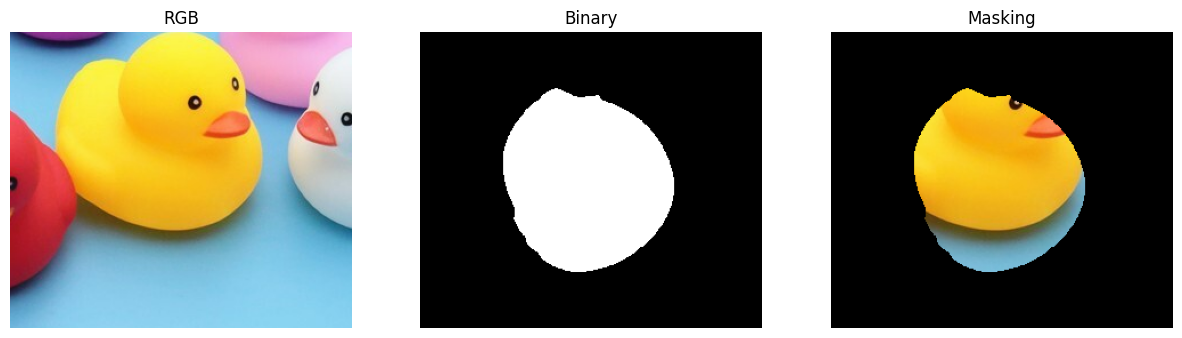

In [19]:
!pip install scikit-image

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.color import rgb2gray
from skimage import io
from skimage.segmentation import active_contour

# ==========================
# Membaca gambar
# ==========================
img = io.imread('/content/mainanjpg.jpg')

# Jika RGBA ubah ke RGB
if img.shape[-1] == 4:
    img = img[:, :, :3]

# ==========================
# Ambil area bebek kuning tengah bawah (crop)
# ==========================
crop = img[430:690, 260:560]

# ==========================
# Grayscale
# ==========================
gray = rgb2gray(crop)

# ==========================
# Contour awal di tengah crop
# ==========================
s = np.linspace(0, 2*np.pi, 400)

x = 150 + 80*np.cos(s)
y = 130 + 80*np.sin(s)

init = np.array([x, y]).T

# ==========================
# Active contour
# ==========================
snake = active_contour(
    gray,
    init,
    alpha=0.01,
    beta=12,
    gamma=0.001
)

# ==========================
# Binary mask
# ==========================
mask = np.zeros(gray.shape, dtype=np.uint8)
pts = np.array(snake, dtype=np.int32)
cv2.fillPoly(mask, [pts], 255)

# ==========================
# Masking
# ==========================
masked = cv2.bitwise_and(crop, crop, mask=mask)

# ==========================
# Menampilkan hasil
# ==========================
fig, ax = plt.subplots(1,3, figsize=(15,5))

# RGB
ax[0].imshow(crop)
ax[0].set_title("RGB")
ax[0].axis('off')

# Binary
ax[1].imshow(mask, cmap='gray')
ax[1].set_title("Binary")
ax[1].axis('off')

# Masking
ax[2].imshow(masked)
ax[2].set_title("Masking")
ax[2].axis('off')

plt.show()

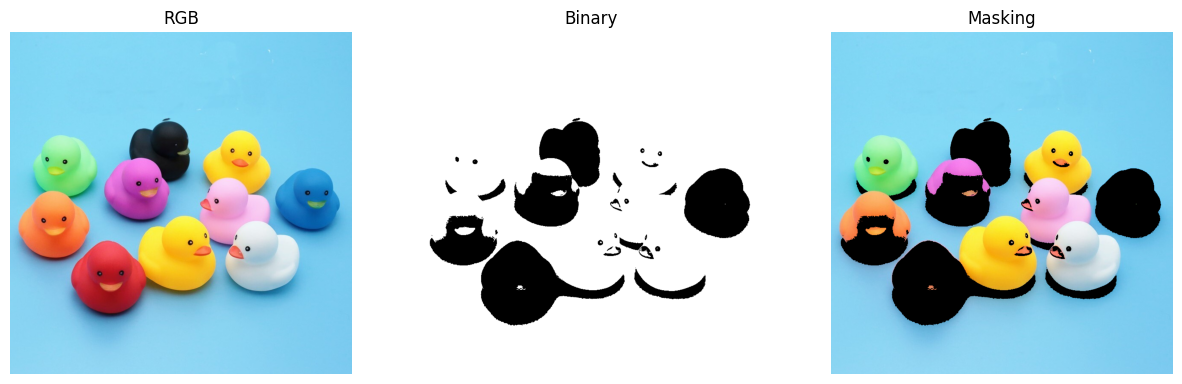

In [12]:
import cv2
import matplotlib.pyplot as plt

# ==========================
# Membaca gambar
# ==========================
img = cv2.imread('/content/mainanjpg.jpg')

# Ubah ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================
# Grayscale
# ==========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# Thresholding
# ==========================
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

# ==========================
# Masking hasil threshold
# ==========================
result = cv2.bitwise_and(img_rgb, img_rgb, mask=thresh)

# ==========================
# Menampilkan hasil
# ==========================
fig, ax = plt.subplots(1,3, figsize=(15,5))

# RGB
ax[0].imshow(img_rgb)
ax[0].set_title("RGB")
ax[0].axis('off')

# Binary
ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Binary")
ax[1].axis('off')

# Masking
ax[2].imshow(result)
ax[2].set_title("Masking")
ax[2].axis('off')

plt.show()

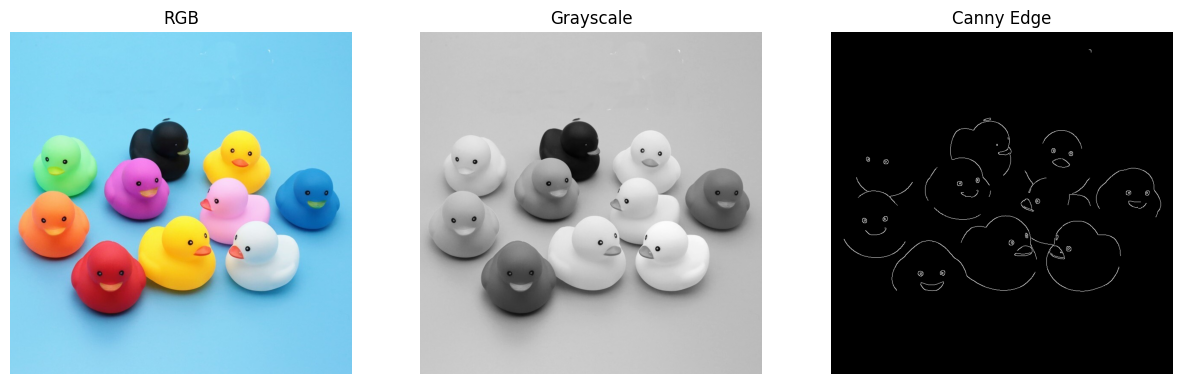

In [13]:
import cv2
import matplotlib.pyplot as plt

# ==========================
# Membaca gambar
# ==========================
img = cv2.imread('/content/mainanjpg.jpg')

# Ubah ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================
# Grayscale
# ==========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# Canny Edge Detection
# ==========================
edges = cv2.Canny(gray, 100, 200)

# ==========================
# Menampilkan hasil
# ==========================
fig, ax = plt.subplots(1,3, figsize=(15,5))

# RGB
ax[0].imshow(img_rgb)
ax[0].set_title("RGB")
ax[0].axis('off')

# Grayscale
ax[1].imshow(gray, cmap='gray')
ax[1].set_title("Grayscale")
ax[1].axis('off')

# Edge Detection
ax[2].imshow(edges, cmap='gray')
ax[2].set_title("Canny Edge")
ax[2].axis('off')

plt.show()

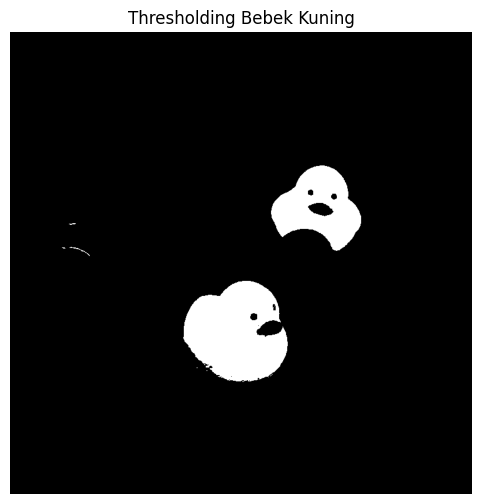

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv2.imread('/content/mainanjpg.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Ambil warna kuning
lower = np.array([20, 100, 100])
upper = np.array([35, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

# Threshold hasil kuning
_, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# Tampilkan hasil
plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholding Bebek Kuning")
plt.axis('off')
plt.show()